# Decision Tree Worksheet

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

## YOUR CODE HERE
data = pd.read_csv(url, names=names)
from sklearn.model_selection import train_test_split


X = data.drop('class', axis=1)
y = data['class']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=100
)

## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [ ]:
## YOUR CODE HERE
overfit_model = DecisionTreeClassifier(max_depth=100, min_samples_leaf=2)
overfit_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=100, min_samples_leaf=2)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
overfit_train_pred = overfit_model.predict(X_train)
overfit_val_pred = overfit_model.predict(X_val)

print(f"\noverfit model training accuracy: {accuracy_score(y_train, overfit_train_pred)*100:.2f}%")
print(f"overfit model validation accuracy: {accuracy_score(y_val, overfit_val_pred)*100:.2f}%")


overfit model training accuracy: 95.65%
overfit model validation accuracy: 73.38%


Make a model with a low max-depth and higher minimum sample leafs.

In [ ]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

print(f"\nregular model training accuracy: {accuracy_score(y_train, train_pred)*100:.2f}%")
print(f"regular model validation accuracy: {accuracy_score(y_val, val_pred)*100:.2f}%")


regular model training accuracy: 82.39%
regular model validation accuracy: 75.97%


Explain the accuracy results below.

(YOUR ANSWER HERE)

Due to the max depth of the first model being so large, the model is overfitting and "remembering" the train data, leading to greater train accuracy comparitively to the 2nd model, but less validation accuracy.

## Metrics

Plot the ROC curve and print the AUC of the second model.

0.770222305249393


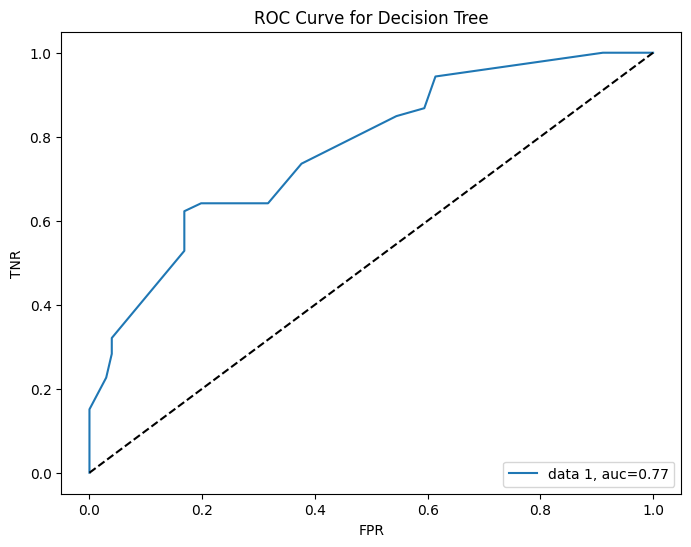

In [ ]:
## YOUR CODE HERE
y_pred_proba = model.predict_proba(X_val)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_val,  y_pred_proba)
auc = metrics.roc_auc_score(y_val, y_pred_proba)
print(auc)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"data 1, auc={auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Decision Tree')
plt.xlabel('FPR')
plt.ylabel('TNR')
plt.legend(loc=4)
plt.show()

Use graphviz to visualize your 2nd tree.

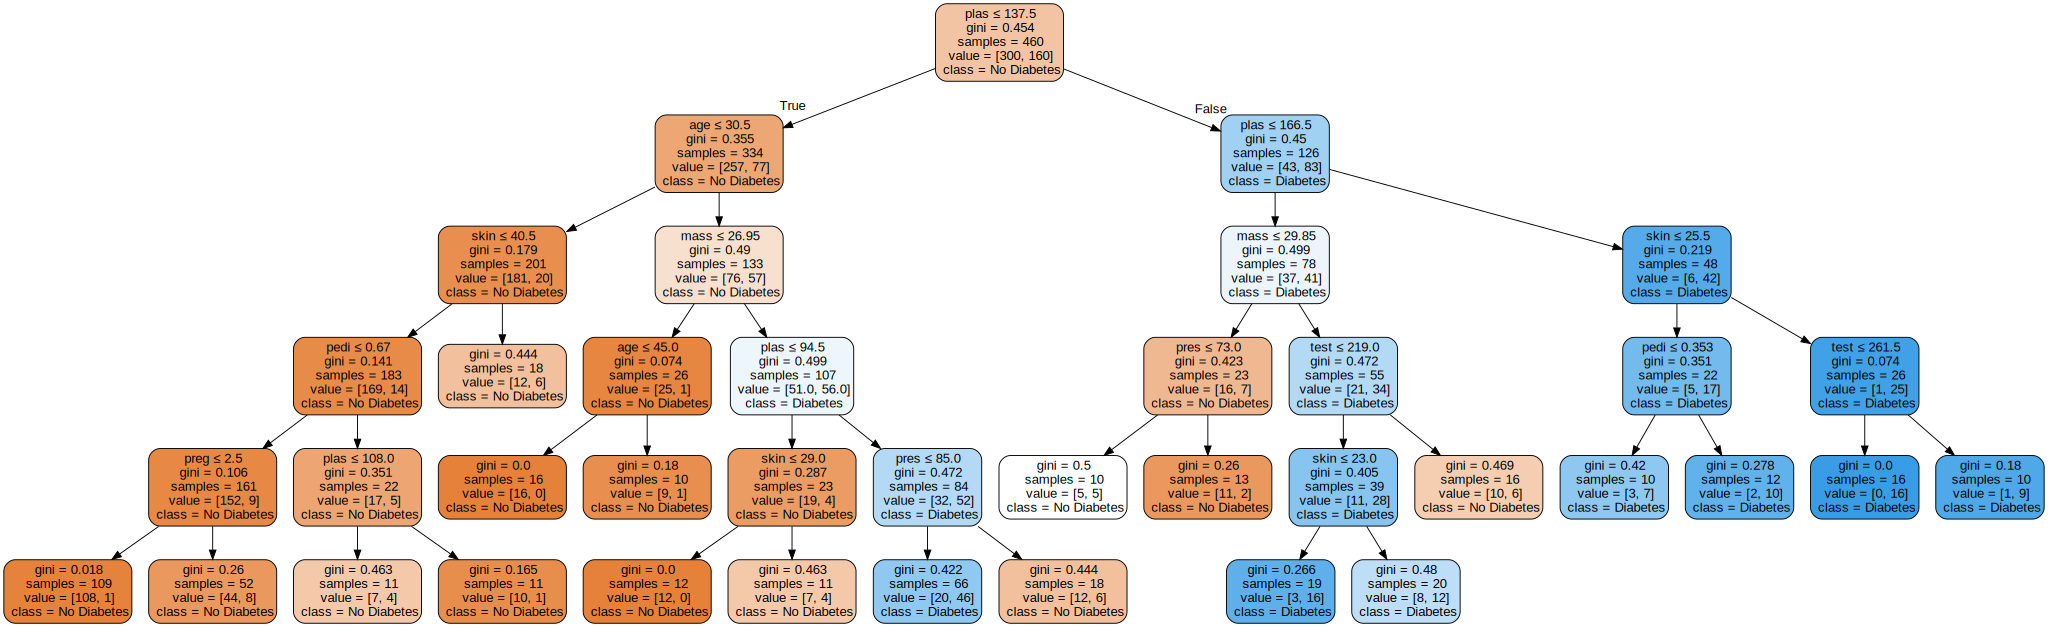

In [ ]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(model, out_file=None,
                                feature_names=names[:-1], #all names except 'class'
                                class_names=['No Diabetes', 'Diabetes'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

(YOUR ANSWER HERE)

X[n] represents the feature at index n from out feature list (i.e. X[1] is 'plas', X[5] is 'mass', and X[7] is 'age')

Question 2: What is the root feature? Does it make sense as the root feature?

(YOUR ANSWER HERE)

The root feature is 'plas' and it makes sense because plas/blood glucose level is primary factor in diagnosis of diabetes.

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

(YOUR ANSWER HERE)

Training accuracy would most likely be 100%, and test accuracy would be significantly lower as the model is extremely overfit.

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [ ]:
## YOUR CODE HERE
model_guess_test = DecisionTreeClassifier(max_depth=500, min_samples_leaf=1, random_state=42)
model_guess_test.fit(X_train, y_train)

train_pred_guess = model_guess_test.predict(X_train)
val_pred_guess = model_guess_test.predict(X_test)

print(f"\ntest model training accuracy: {accuracy_score(y_train, train_pred_guess)*100:.2f}%")
print(f"test model validation accuracy: {accuracy_score(y_test, val_pred_guess)*100:.2f}%")


test model training accuracy: 100.00%
test model validation accuracy: 64.94%


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [ ]:
## YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Print accuracy of training and validation data.

In [ ]:
## YOUR CODE HERE
train_pred_rf = rf_model.predict(X_train)
val_pred_rf = rf_model.predict(X_test)

print(f"\nrandom forest training accuracy: {accuracy_score(y_train, train_pred_rf)*100:.2f}%")
print(f"random forest validation accuracy: {accuracy_score(y_test, val_pred_rf)*100:.2f}%")


random forest training accuracy: 100.00%
random forest validation accuracy: 75.32%


How did the accuracy compare to the decision tree's accuracy?

(YOUR ANSWER HERE)

The validation accuracy greatly overperforms the 1st overfitted model and slightly underperforms when compared against the 2nd model.

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [ ]:
## YOUR CODE HERE
feature_importances = pd.Series(rf_model.feature_importances_, index=names[:-1]).sort_values(ascending=False)
print("\ntop 3 most important features:")
print(feature_importances.head(3))


top 3 most important features:
plas    0.237451
age     0.157238
mass    0.151664
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.

trees: 1, Accuracy: 66.23%
trees: 6, Accuracy: 68.83%
trees: 11, Accuracy: 70.78%
trees: 16, Accuracy: 68.83%
trees: 21, Accuracy: 69.48%
trees: 26, Accuracy: 72.73%
trees: 31, Accuracy: 70.78%
trees: 36, Accuracy: 70.78%
trees: 41, Accuracy: 73.38%
trees: 46, Accuracy: 73.38%
trees: 51, Accuracy: 73.38%
trees: 56, Accuracy: 72.73%
trees: 61, Accuracy: 73.38%
trees: 66, Accuracy: 73.38%
trees: 71, Accuracy: 74.03%
trees: 76, Accuracy: 74.68%
trees: 81, Accuracy: 75.97%
trees: 86, Accuracy: 74.68%
trees: 91, Accuracy: 76.62%
trees: 96, Accuracy: 75.32%


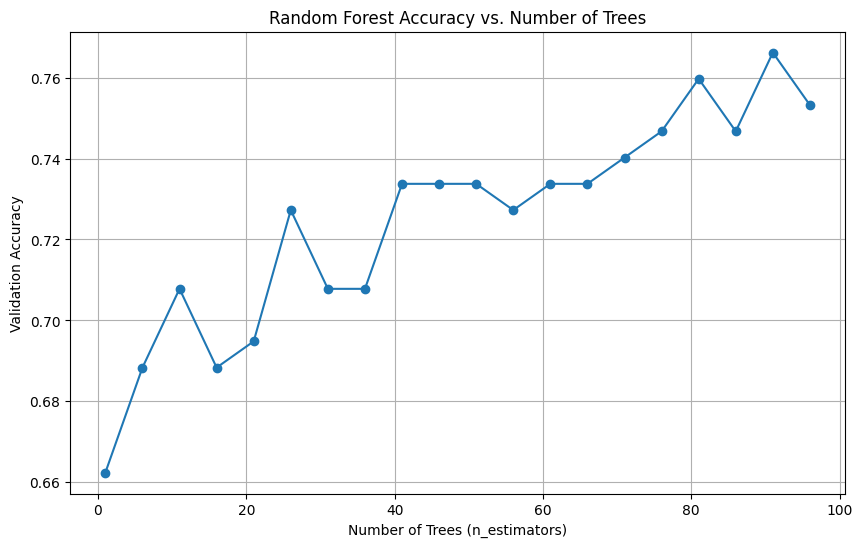

In [ ]:
## YOUR CODE HERE
n_estimators_range = range(1, 101, 5)
accuracies = []

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"trees: {n}, Accuracy: {accuracy*100:.2f}%")

plt.figure(figsize=(10,6))
plt.plot(n_estimators_range, accuracies, marker='o')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

AUC of the Random Forest model: 0.8344


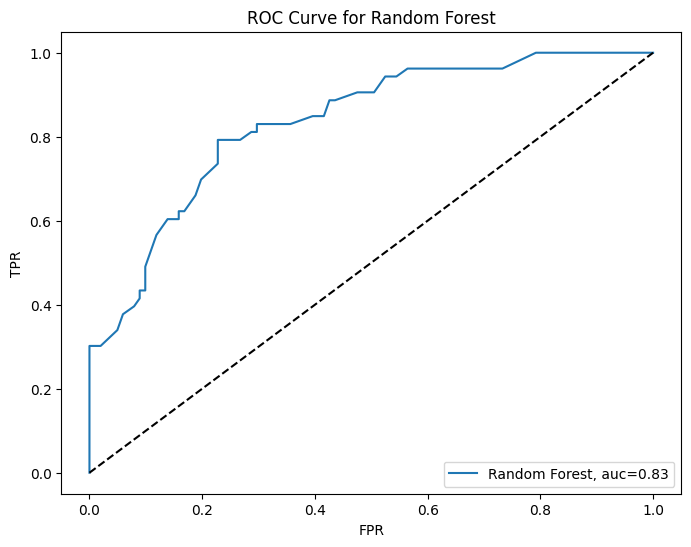

In [ ]:
## YOUR CODE HERE
y_pred_proba_rf = rf_model.predict_proba(X_val)[:,1]
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_val, y_pred_proba_rf)
auc_rf = metrics.roc_auc_score(y_val, y_pred_proba_rf)
print(f"AUC of the Random Forest model: {auc_rf:.4f}")

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest, auc={auc_rf:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc=4)
plt.show()